In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
import pandas as pd

df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2,30,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3,65,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4,55,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5,58,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6,23,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [41]:
print("Shape:", df.shape)
print(df.columns.tolist())


Shape: (82397, 12)
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']


In [42]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
82392,84575,24,Female,59.0,11.0,5.0,16.0,Basic,Monthly,448.0,2.0,1.0
82393,84576,56,Male,5.0,22.0,8.0,3.0,Standard,Monthly,383.0,10.0,1.0
82394,84577,36,Male,2.0,11.0,10.0,23.0,Basic,Quarterly,428.0,16.0,1.0
82395,84578,58,Male,15.0,24.0,7.0,16.0,Basic,Annual,800.0,15.0,1.0
82396,84579,51,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
df.dtypes
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [44]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


# 0 = No churn
# 1 = Churn

In [45]:
print(df["Churn"].value_counts())

Churn
1.0    81068
0.0     1328
Name: count, dtype: int64


identifying numerical col

In [46]:
# Numerical columns identify karna
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Columns:")
print(numerical_cols.tolist())

Numerical Columns:
['CustomerID', 'Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Churn']


In [47]:
df[numerical_cols].describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,82397.000000,82397.000000,82396.000000,82396.000000,82396.000000,82396.000000,82396.000000,82396.000000,82396.000000
mean,41875.298967,41.592643,30.452194,15.464246,5.094592,15.121474,545.709513,15.544626,0.983883
std,24471.212123,13.918348,17.358824,8.691513,3.152920,8.958957,259.508417,8.651094,0.125927
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,20608.000000,29.000000,15.000000,8.000000,2.000000,7.000000,321.000000,8.000000,1.000000
50%,41605.000000,42.000000,30.000000,15.000000,5.000000,15.000000,543.000000,16.000000,1.000000
75%,63111.000000,54.000000,46.000000,23.000000,8.000000,23.000000,770.000000,23.000000,1.000000
max,84579.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


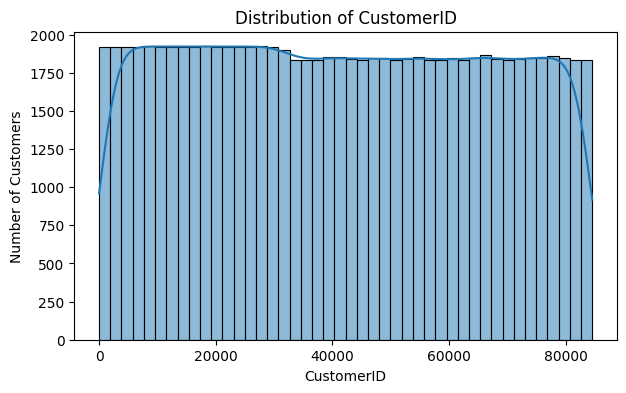

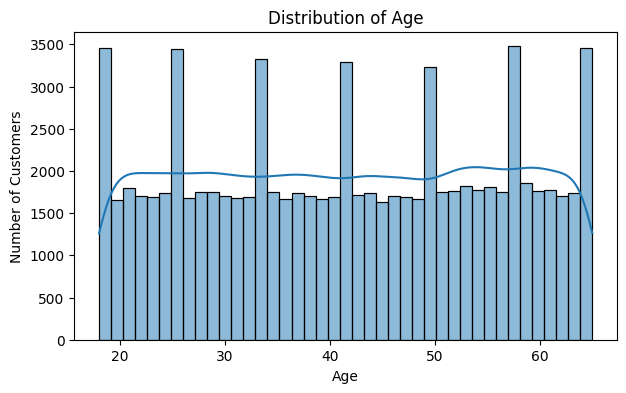

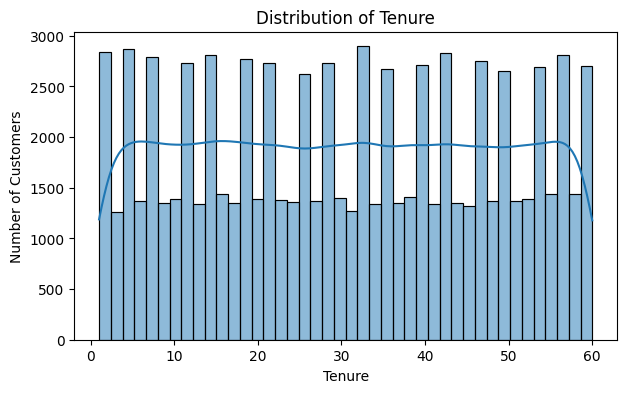

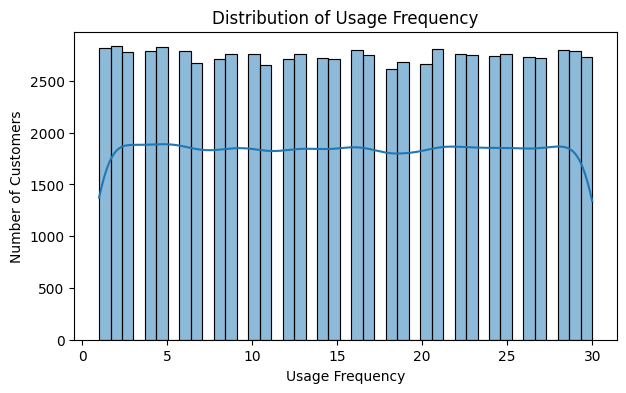

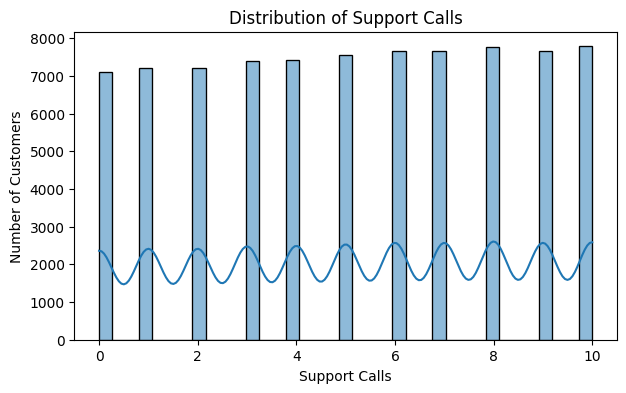

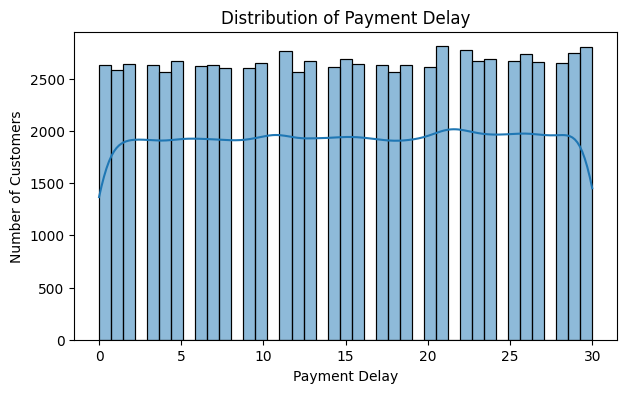

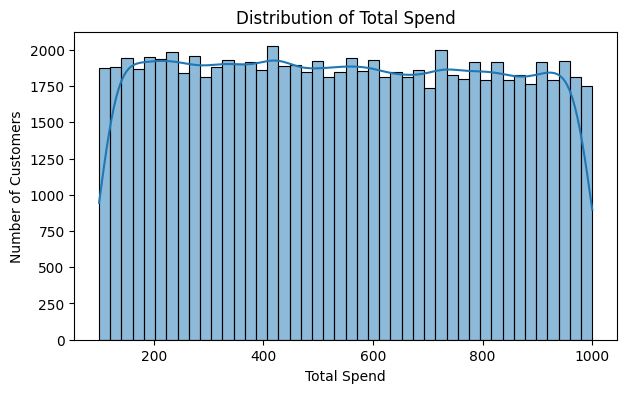

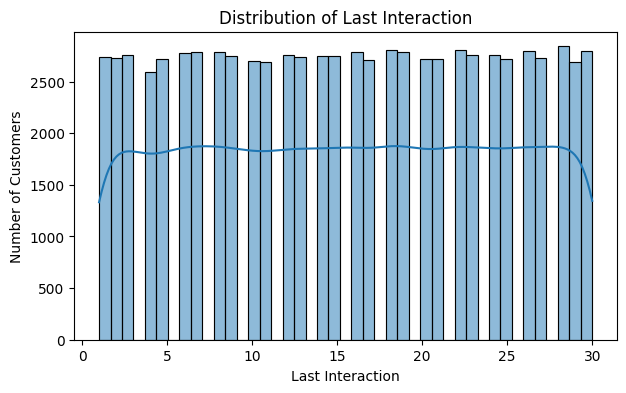

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:

    if col != "Churn":

        plt.figure(figsize=(7, 4))

        sns.histplot(
            data=df,
            x=col,
            kde=True
        )

        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Number of Customers")

        plt.show()

boxplot for outliers


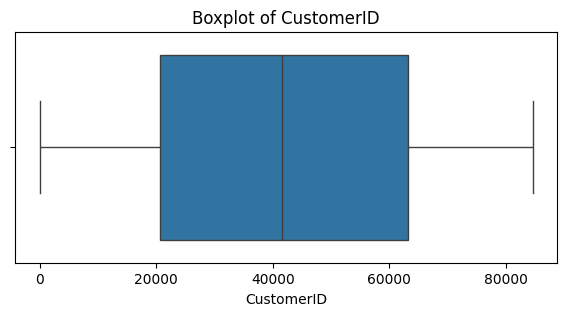

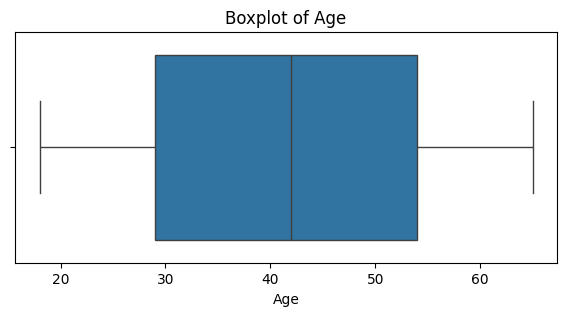

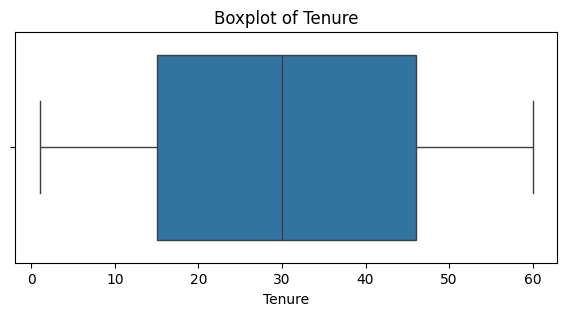

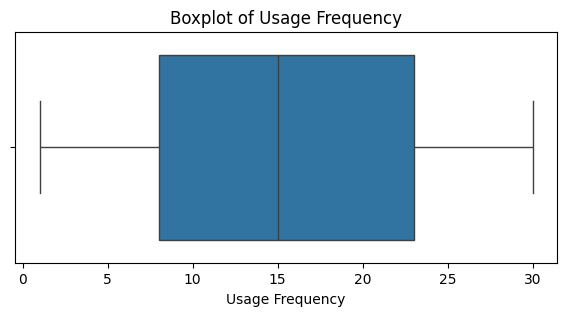

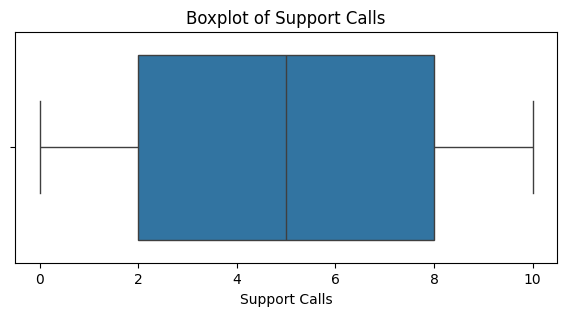

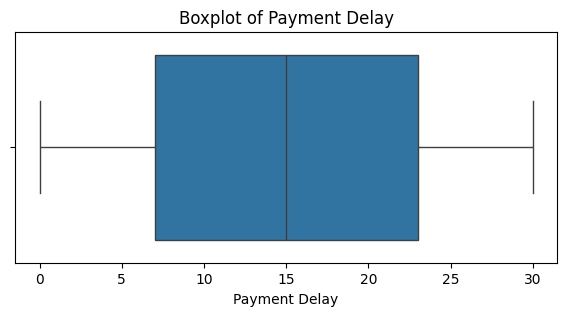

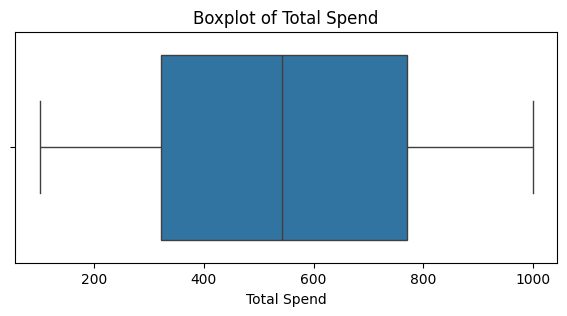

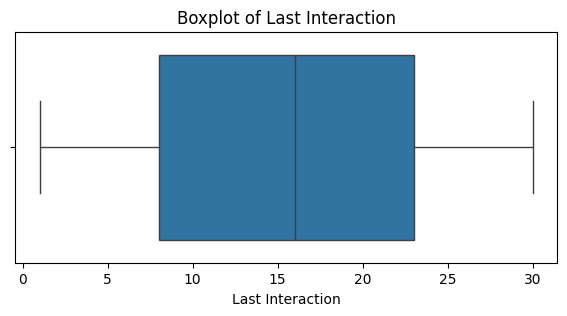

In [49]:
for col in numerical_cols:

    if col != "Churn":

        plt.figure(figsize=(7, 3))

        sns.boxplot(
            x=df[col]
        )

        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)

        plt.show()

identifying categorical columns

In [50]:
categorical_cols = df.select_dtypes(
    include=["object"]
).columns

print("Categorical Columns:")
print(categorical_cols.tolist())

Categorical Columns:
['Gender', 'Subscription Type', 'Contract Length']


visulaizing categorical disribution


Gender
Gender
Female    41679
Male      40717
M             1
Name: count, dtype: int64


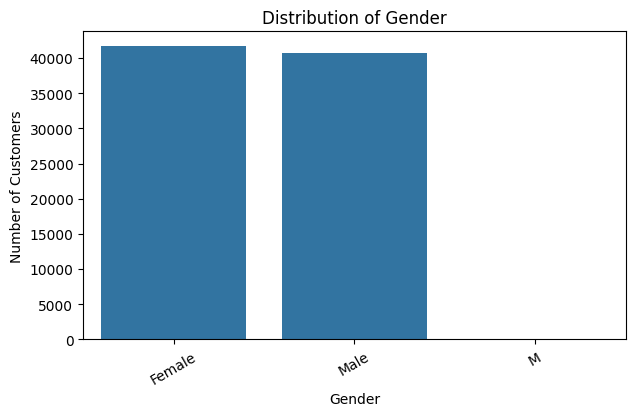


Subscription Type
Subscription Type
Standard    27636
Premium     27590
Basic       27170
Name: count, dtype: int64


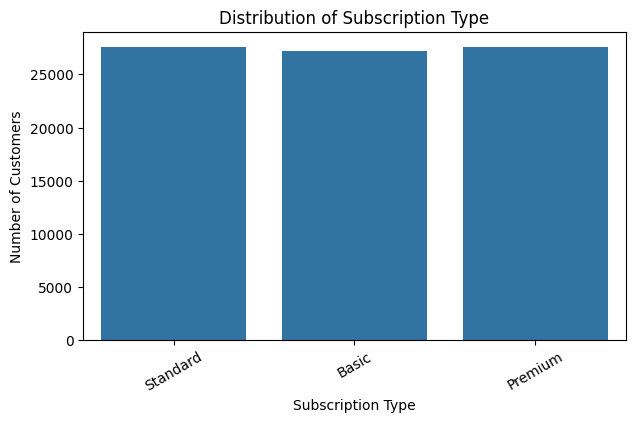


Contract Length
Contract Length
Monthly      28117
Annual       27262
Quarterly    27017
Name: count, dtype: int64


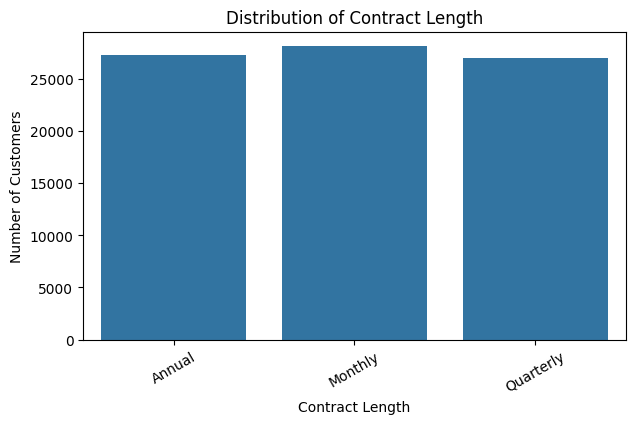

In [51]:
for col in categorical_cols:

    print(f"\n{col}")
    print(df[col].value_counts())

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=30)

    plt.show()

churn k sath relationship (bivariate Analysis)

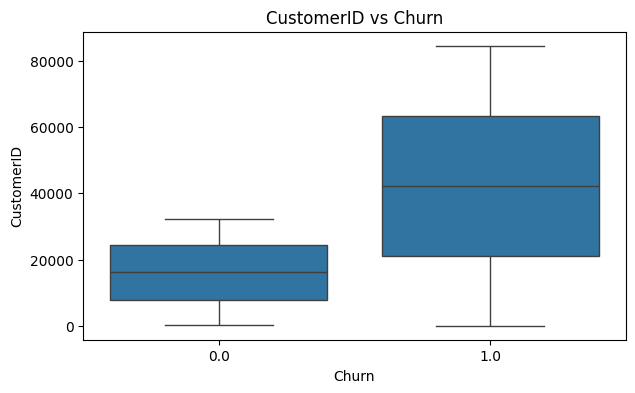

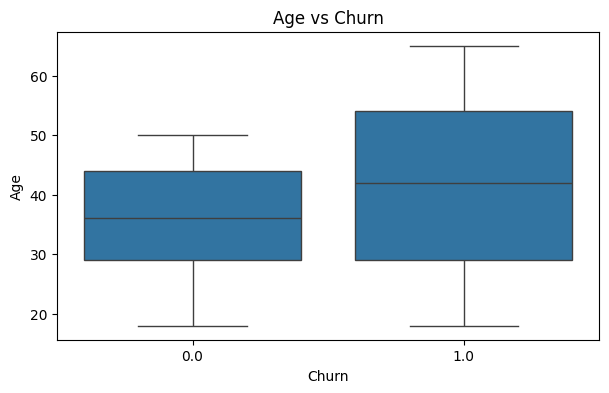

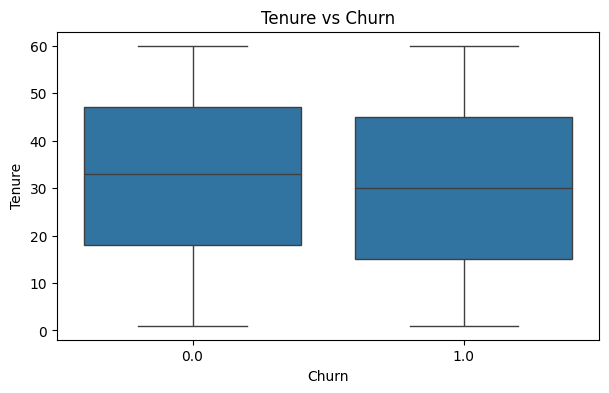

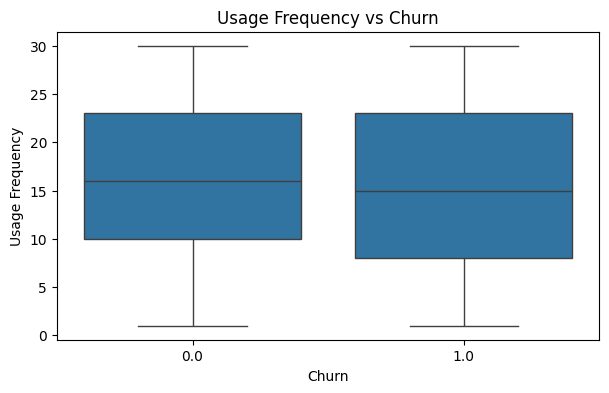

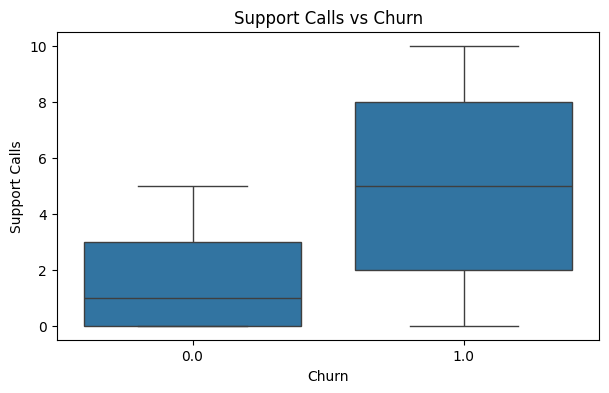

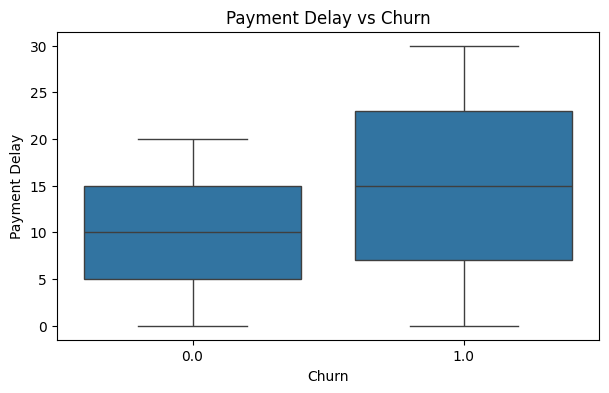

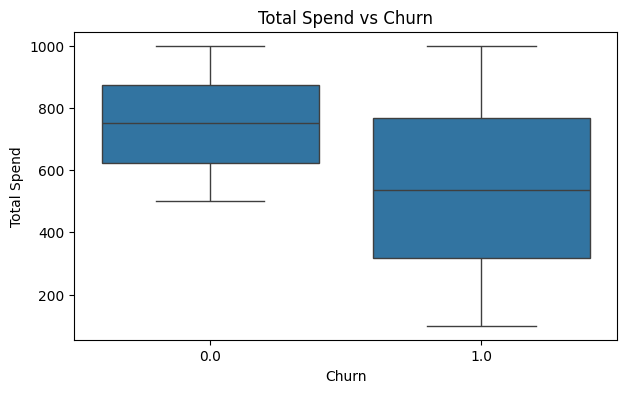

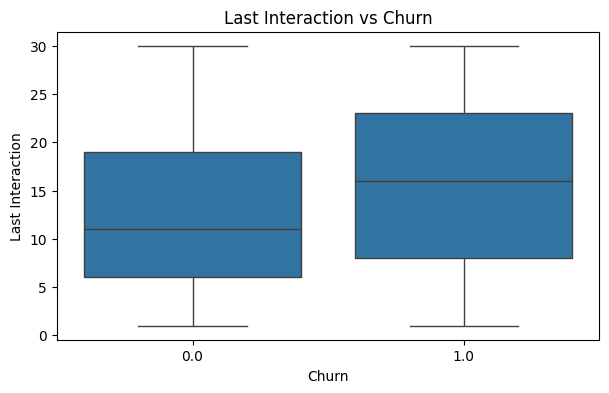

In [52]:


for col in numerical_cols:

    if col != "Churn":

        plt.figure(figsize=(7, 4))

        sns.boxplot(
            data=df,
            x="Churn",
            y=col
        )

        plt.title(f"{col} vs Churn")
        plt.xlabel("Churn")
        plt.ylabel(col)

        plt.show()

Categorical features vs Churn

# 0 = No churn
# 1 = Churn

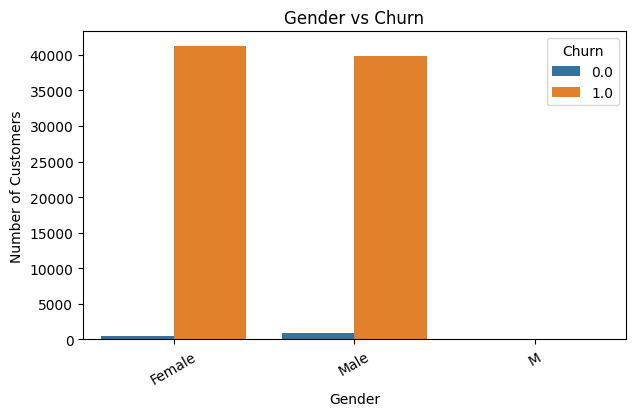

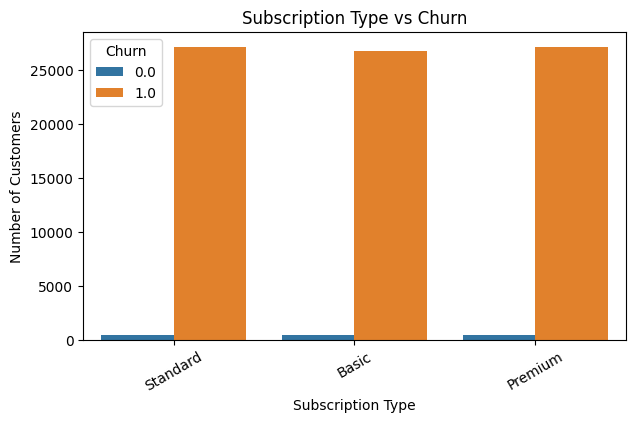

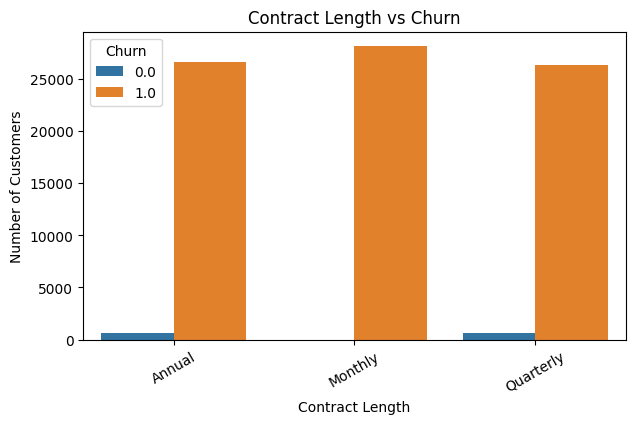

In [53]:
for col in categorical_cols:

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn"
    )

    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Number of Customers")

    plt.xticks(rotation=30)

    plt.show()

churn rate by category

In [54]:
churn_by_contract = pd.crosstab(
    df["Contract Length"],
    df["Churn"],
    normalize="index" #Har contract category ke andar percentages calculate karo.
) * 100

print(churn_by_contract)

Churn                 0.0         1.0
Contract Length                      
Annual           2.461301   97.538699
Monthly          0.000000  100.000000
Quarterly        2.431802   97.568198


Correlation Matrix

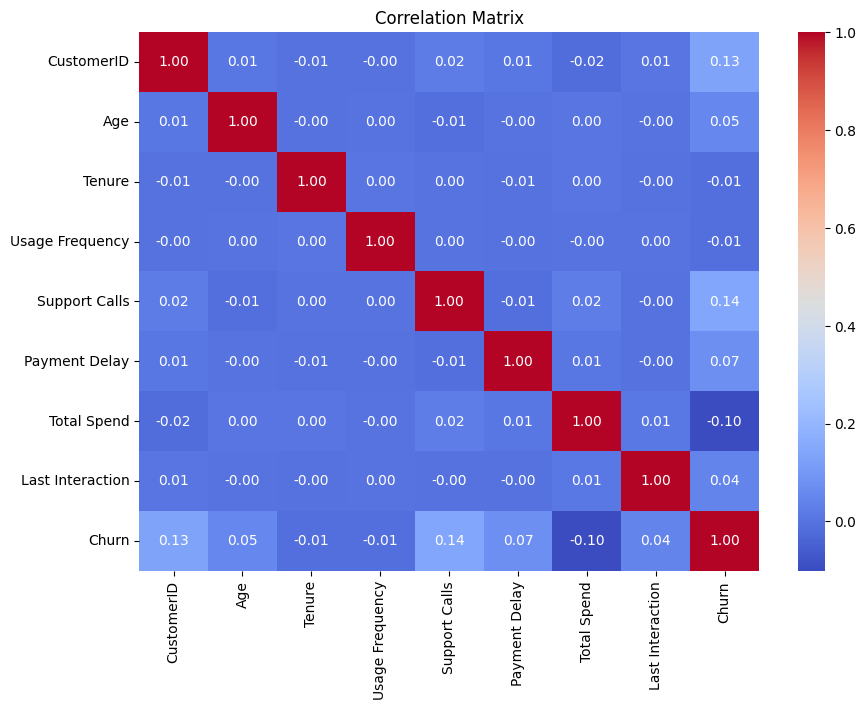

In [55]:
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap( #Heatmap ka purpose: values ko colors ke through easily samajhna.
    correlation,
    annot=True,#annot ka matlab annotation, yani cells ke andar actual number show karna. agr false kringy to num show ni hongy
    cmap="coolwarm", #Ye color map choose karta hai.
             #coolwarm generally:
             #negative correlation → cool/bluish
             #positive correlation → warm/reddish

    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

+1  → strong positive relationship
 0  → little/no linear relationship
-1  → strong negative relationship

In [56]:
churn_correlation = (
    df[numerical_cols]
    .corr()["Churn"]
    .sort_values(ascending=False)
)

print(churn_correlation)

Churn               1.000000
Support Calls       0.143596
CustomerID          0.133971
Payment Delay       0.074114
Age                 0.053290
Last Interaction    0.040933
Usage Frequency    -0.011726
Tenure             -0.013983
Total Spend        -0.101120
Name: Churn, dtype: float64


Churn rate by categorical features

har category ke andar churn hone wale customers ka percentage.


Churn Rate by Gender:
Gender
Female    98.913122
Male      97.851020
M               NaN
Name: Churn, dtype: float64


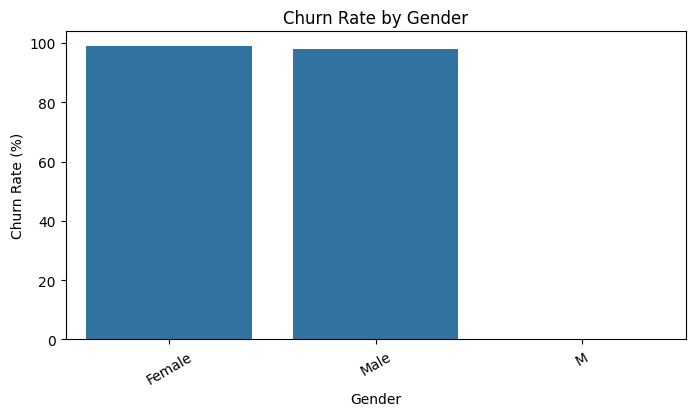


Churn Rate by Subscription Type:
Subscription Type
Basic       98.450497
Premium     98.361725
Standard    98.353597
Name: Churn, dtype: float64


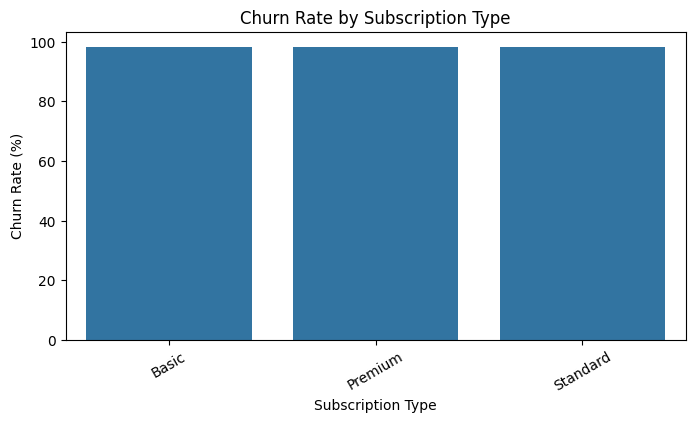


Churn Rate by Contract Length:
Contract Length
Monthly      100.000000
Quarterly     97.568198
Annual        97.538699
Name: Churn, dtype: float64


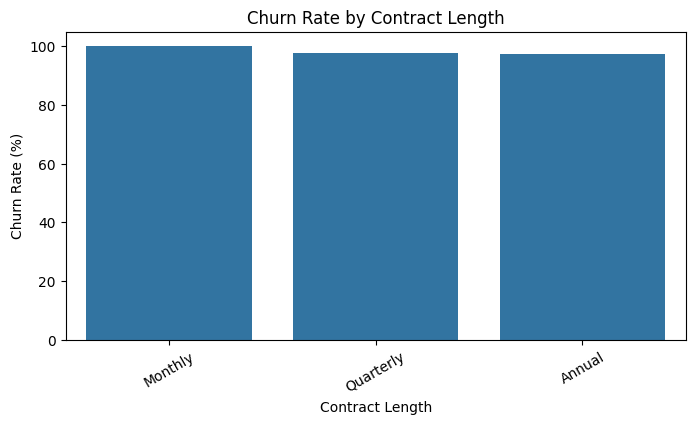

In [57]:
# Categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:

    churn_rate = (
        df.groupby(col)["Churn"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\nChurn Rate by {col}:")
    print(churn_rate)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=churn_rate.index,
        y=churn_rate.values
    )

    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=30)
    plt.show()

numerical features ka churn rate


Churn Rate by Age:
temp_bin
(17.999, 29.0]     98.274612
(29.0, 42.0]       97.372622
(42.0, 54.0]       98.071101
(54.0, 65.0]      100.000000
Name: Churn, dtype: float64


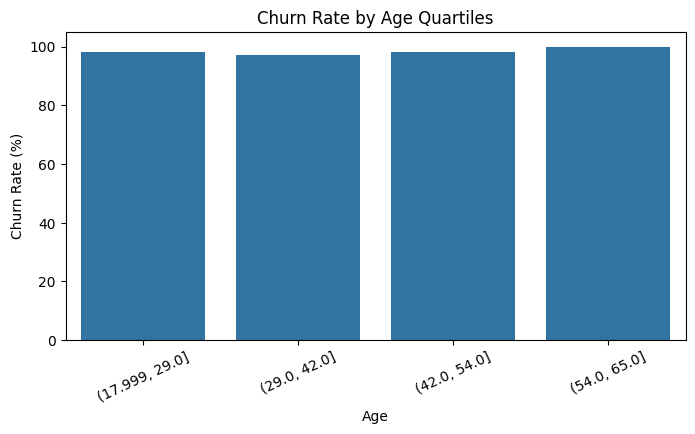


Churn Rate by Tenure:
temp_bin
(0.999, 15.0]    98.543877
(15.0, 30.0]     98.617938
(30.0, 46.0]     98.152974
(46.0, 60.0]     98.242695
Name: Churn, dtype: float64


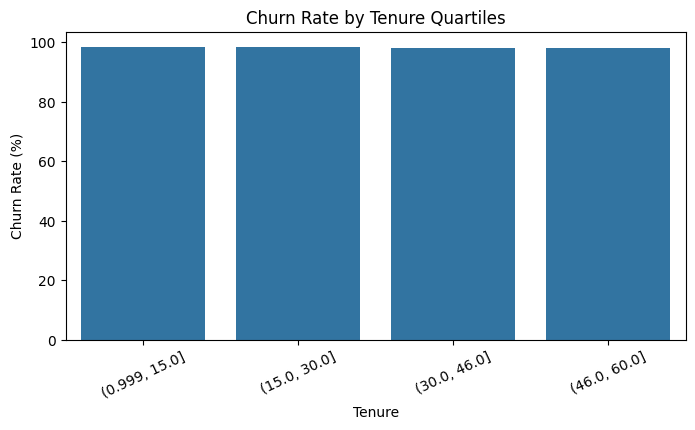


Churn Rate by Usage Frequency:
temp_bin
(0.999, 8.0]    98.712640
(8.0, 15.0]     98.192487
(15.0, 23.0]    98.282180
(23.0, 30.0]    98.328402
Name: Churn, dtype: float64


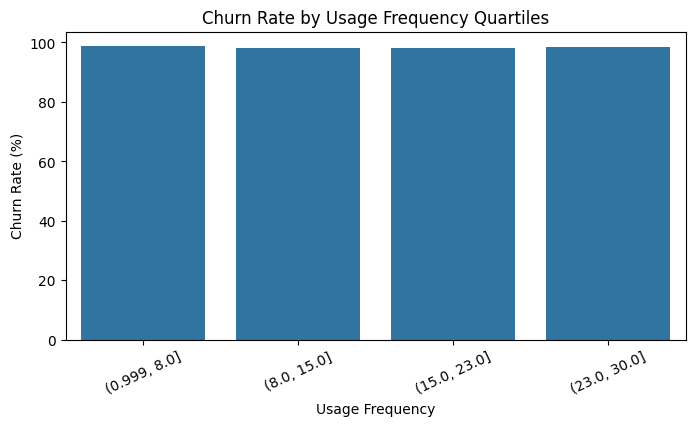


Churn Rate by Support Calls:
temp_bin
(-0.001, 2.0]     95.380106
(2.0, 5.0]        98.501253
(5.0, 8.0]       100.000000
(8.0, 10.0]      100.000000
Name: Churn, dtype: float64


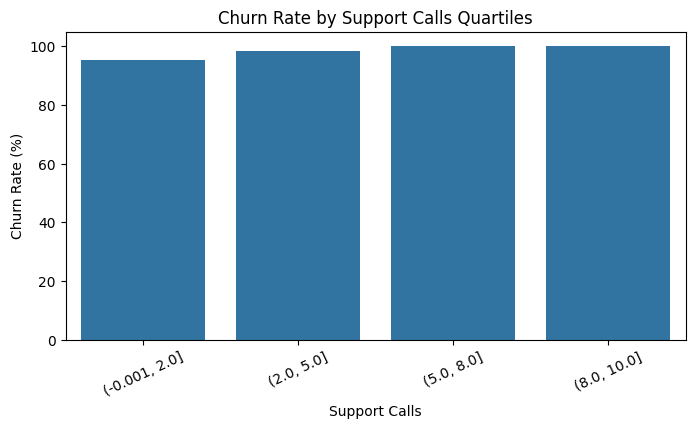


Churn Rate by Payment Delay:
temp_bin
(-0.001, 7.0]     97.533279
(7.0, 15.0]       97.626029
(15.0, 23.0]      98.552015
(23.0, 30.0]     100.000000
Name: Churn, dtype: float64


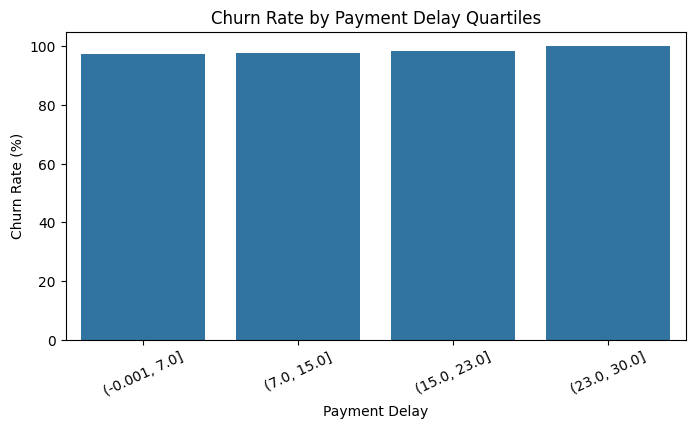


Churn Rate by Total Spend:
temp_bin
(99.999, 321.0]    100.000000
(321.0, 543.0]      99.475474
(543.0, 770.0]      97.061680
(770.0, 1000.0]     97.010790
Name: Churn, dtype: float64


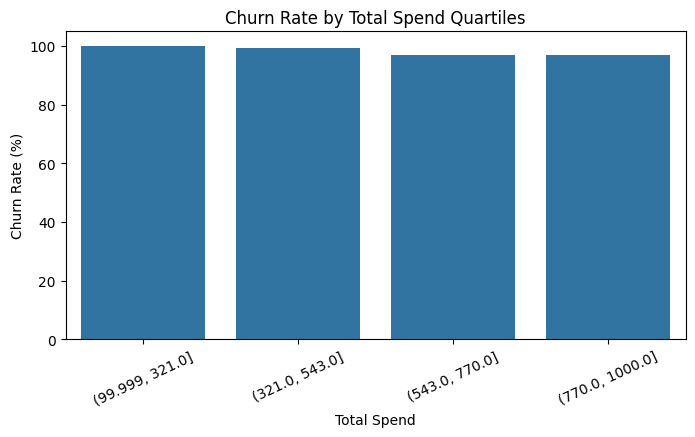


Churn Rate by Last Interaction:
temp_bin
(0.999, 8.0]    97.795765
(8.0, 16.0]     97.995891
(16.0, 23.0]    98.953476
(23.0, 30.0]    98.939033
Name: Churn, dtype: float64


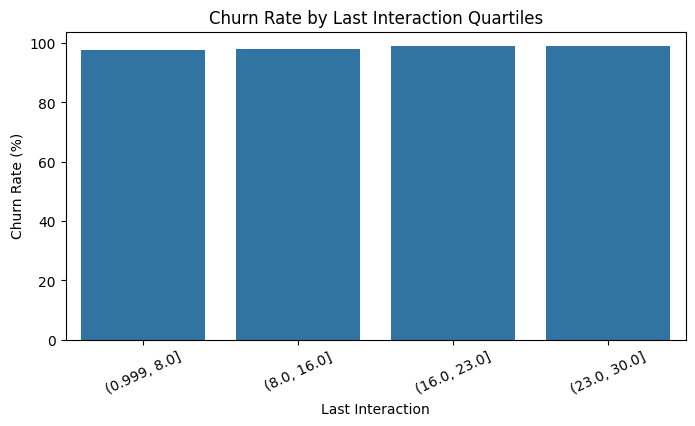

In [58]:
numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction"
]
#pd.qcut() kya hai?

#Ye numerical values ko 4 groups mein divide karta hai:

'''Q1 → lowest 25%
Q2 → next 25%
Q3 → next 25%
Q4 → highest 25%'''

for col in numerical_features:

    df["temp_bin"] = pd.qcut(
        df[col],
        q=4,
        duplicates="drop"
    )

    churn_rate = (
        df.groupby("temp_bin", observed=True)["Churn"]
        .mean()
        * 100
    )

    print(f"\nChurn Rate by {col}:")
    print(churn_rate)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=churn_rate.index.astype(str),
        y=churn_rate.values
    )

    plt.title(f"Churn Rate by {col} Quartiles")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")

    plt.xticks(rotation=25)
    plt.show()

df.drop(columns="temp_bin", inplace=True)

Overall feature relationship

In [59]:
churn_correlation = (
    df[numerical_features + ["Churn"]]
    .corr()["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

print("Correlation with Churn:")
print(churn_correlation)

Correlation with Churn:
Support Calls       0.143596
Payment Delay       0.074114
Age                 0.053290
Last Interaction    0.040933
Usage Frequency    -0.011726
Tenure             -0.013983
Total Spend        -0.101120
Name: Churn, dtype: float64


Feature Engineering

Support Calls = 8 aur Tenure = 2 months hai, to model ke liye ek new feature Support_Calls_per_Tenure useful ho sakta hai.

In [60]:
df_fe = df.copy()

df_fe["Total_Activity"] = (
    df_fe["Usage Frequency"] + df_fe["Support Calls"]
)

df_fe["Support_Calls_per_Tenure"] = (
    df_fe["Support Calls"] / (df_fe["Tenure"] + 1)
)

df_fe["Payment_Delay_per_Tenure"] = (
    df_fe["Payment Delay"] / (df_fe["Tenure"] + 1)
)

df_fe = df_fe.dropna(subset=["Churn"])

df_fe = df_fe.drop(columns=["CustomerID"])

print("Clean feature-engineered dataset:", df_fe.shape)

Clean feature-engineered dataset: (82396, 14)


In [61]:
# Make a copy before feature engineering
df_fe = df.copy()

# 1. Total customer activity
df_fe["Total_Activity"] = (
    df_fe["Usage Frequency"] + df_fe["Support Calls"]
)

# 2. Support calls relative to tenure
df_fe["Support_Calls_per_Tenure"] = (
    df_fe["Support Calls"] / (df_fe["Tenure"] + 1)
)

# 3. Payment delay relative to tenure
df_fe["Payment_Delay_per_Tenure"] = (
    df_fe["Payment Delay"] / (df_fe["Tenure"] + 1)
)

# Check new features
df_fe[
    [
        "Usage Frequency",
        "Support Calls",
        "Tenure",
        "Payment Delay",
        "Total_Activity",
        "Support_Calls_per_Tenure",
        "Payment_Delay_per_Tenure"
    ]
].head()

,Usage Frequency,Support Calls,Tenure,Payment Delay,Total_Activity,Support_Calls_per_Tenure,Payment_Delay_per_Tenure
0,14.0,5.0,39.0,18.0,19.0,0.125000,0.450000
1,1.0,10.0,49.0,8.0,11.0,0.200000,0.160000
2,4.0,6.0,14.0,18.0,10.0,0.400000,1.200000
3,21.0,7.0,38.0,7.0,28.0,0.179487,0.179487
4,20.0,5.0,32.0,8.0,25.0,0.151515,0.242424


Check whether new features are useful

In [62]:
new_features = [
    "Total_Activity",
    "Support_Calls_per_Tenure",
    "Payment_Delay_per_Tenure"
]

print("Correlation with Churn:")

print(
    df_fe[new_features + ["Churn"]]
    .corr()["Churn"]
    .drop("Churn")
    .sort_values(ascending=False)
)

Correlation with Churn:
Support_Calls_per_Tenure    0.055678
Total_Activity              0.037936
Payment_Delay_per_Tenure    0.031134
Name: Churn, dtype: float64


In [63]:
#Remove CustomerID
df_fe = df_fe.drop(columns=["CustomerID"])

print(df_fe.shape)
print(df_fe.columns.tolist())

(82397, 14)
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn', 'Total_Activity', 'Support_Calls_per_Tenure', 'Payment_Delay_per_Tenure']


Train/Test Split

In [64]:
from sklearn.model_selection import train_test_split

# Drop rows where 'Churn' is NaN before splitting
df_cleaned = df_fe.dropna(subset=["Churn"])

# Features
X = df_cleaned.drop(columns=["Churn"])

# Target
y = df_cleaned["Churn"]

# Convert 'Churn' to integer type if it's float after dropping NaNs, for stratification compatibility
y = y.astype(int)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (65916, 13)
X_test shape: (16480, 13)
y_train shape: (65916,)
y_test shape: (16480,)


Preprocessing Pipeline

In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Categorical columns
categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

# Numerical columns
numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    "Total_Activity",
    "Support_Calls_per_Tenure",
    "Payment_Delay_per_Tenure"
]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [66]:
from sklearn.model_selection import train_test_split

# Drop rows where 'Churn' is NaN before splitting
df_fe_cleaned = df_fe.dropna(subset=["Churn"])

X = df_fe_cleaned.drop(columns=["Churn"])
y = df_fe_cleaned["Churn"]

# Convert 'Churn' to integer type for stratification compatibility
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTarget distribution:")
print(y.value_counts())

X_train: (65916, 13)
X_test : (16480, 13)
y_train: (65916,)
y_test : (16480,)

Target distribution:
Churn
1    81068
0     1328
Name: count, dtype: int64


In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Gender",
    "Subscription Type",
    "Contract Length"
]

numerical_features = [
    "Age",
    "Tenure",
    "Usage Frequency",
    "Support Calls",
    "Payment Delay",
    "Total Spend",
    "Last Interaction",
    "Total_Activity",
    "Support_Calls_per_Tenure",
    "Payment_Delay_per_Tenure"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [68]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

'''fit_transform(X_train) → training data se preprocessing rules seekhta hai aur phir training data transform karta hai.
transform(X_test) → wahi learned rules test data par apply karta hai.
Test data par dobara fit nahi karte, warna data leakage ho sakti hai.'''


print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape :", X_test_processed.shape)

X_train_processed shape: (65916, 18)
X_test_processed shape : (16480, 18)


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss"
)

print("All models created successfully!")

All models created successfully!


Train all 3

In [71]:
logistic_model.fit(X_train_processed, y_train)

random_forest_model.fit(X_train_processed, y_train)

xgb_model.fit(X_train_processed, y_train)

print("All models trained successfully!")

All models trained successfully!


predict() vs predict_proba()


predict() gives the final class:

Whereas:

predict_proba()

gives probability:

No Churn = 0.20
Churn    = 0.80

[:, 1] means:

Har customer ke liye Churn (class 1) ki probability lo.

In [72]:

y_pred_lr = logistic_model.predict(X_test_processed)
y_pred_rf = random_forest_model.predict(X_test_processed)
y_pred_xgb = xgb_model.predict(X_test_processed)

y_prob_lr = logistic_model.predict_proba(X_test_processed)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_test_processed)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


Evaluation Function

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    print(f"\n{name}")
    print("-" * 30)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

Evaluate all 3 models

In [74]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_lr,
    y_prob_lr
)

evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)

evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)


Logistic Regression
------------------------------
Accuracy : 0.9840
Precision: 0.9857
Recall   : 0.9981
F1 Score : 0.9919
ROC-AUC  : 0.9648

Random Forest
------------------------------
Accuracy : 0.9959
Precision: 0.9961
Recall   : 0.9997
F1 Score : 0.9979
ROC-AUC  : 0.9947

XGBoost
------------------------------
Accuracy : 0.9992
Precision: 0.9992
Recall   : 0.9999
F1 Score : 0.9996
ROC-AUC  : 0.9998


Train vs Test Stability

In [75]:
from sklearn.metrics import confusion_matrix, classification_report

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\nRandom Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("\nXGBoost")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Logistic Regression
[[   32   234]
 [   30 16184]]
              precision    recall  f1-score   support

           0       0.52      0.12      0.20       266
           1       0.99      1.00      0.99     16214

    accuracy                           0.98     16480
   macro avg       0.75      0.56      0.59     16480
weighted avg       0.98      0.98      0.98     16480


Random Forest
[[  203    63]
 [    5 16209]]
              precision    recall  f1-score   support

           0       0.98      0.76      0.86       266
           1       1.00      1.00      1.00     16214

    accuracy                           1.00     16480
   macro avg       0.99      0.88      0.93     16480
weighted avg       1.00      1.00      1.00     16480


XGBoost
[[  253    13]
 [    1 16213]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       266
           1       1.00      1.00      1.00     16214

    accuracy                           1.00  

In [76]:
# Compare train vs test performance

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    train_pred = model.predict(X_train_processed)
    test_pred = model.predict(X_test_processed)

    train_prob = model.predict_proba(X_train_processed)[:, 1]
    test_prob = model.predict_proba(X_test_processed)[:, 1]

    print(f"\n{name}")
    print("-" * 40)

    print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.4f}")
    print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

    print(f"Train F1       : {f1_score(y_train, train_pred):.4f}")
    print(f"Test F1        : {f1_score(y_test, test_pred):.4f}")

    print(f"Train ROC-AUC  : {roc_auc_score(y_train, train_prob):.4f}")
    print(f"Test ROC-AUC   : {roc_auc_score(y_test, test_prob):.4f}")


Logistic Regression
----------------------------------------
Train Accuracy : 0.9844
Test Accuracy  : 0.9840
Train F1       : 0.9921
Test F1        : 0.9919
Train ROC-AUC  : 0.9602
Test ROC-AUC   : 0.9648

Random Forest
----------------------------------------
Train Accuracy : 1.0000
Test Accuracy  : 0.9959
Train F1       : 1.0000
Test F1        : 0.9979
Train ROC-AUC  : 1.0000
Test ROC-AUC   : 0.9947

XGBoost
----------------------------------------
Train Accuracy : 1.0000
Test Accuracy  : 0.9992
Train F1       : 1.0000
Test F1        : 0.9996
Train ROC-AUC  : 1.0000
Test ROC-AUC   : 0.9998


In [77]:
feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.Series(
    random_forest_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(rf_importance)

Random Forest Feature Importance:
numerical__Age                             0.182235
numerical__Total Spend                     0.153737
numerical__Last Interaction                0.089098
numerical__Payment Delay                   0.086162
numerical__Support Calls                   0.073787
numerical__Support_Calls_per_Tenure        0.072000
numerical__Payment_Delay_per_Tenure        0.062254
numerical__Tenure                          0.054705
categorical__Contract Length_Monthly       0.043098
numerical__Total_Activity                  0.039389
numerical__Usage Frequency                 0.037051
categorical__Gender_Male                   0.026678
categorical__Gender_Female                 0.025943
categorical__Contract Length_Annual        0.018461
categorical__Contract Length_Quarterly     0.016173
categorical__Subscription Type_Basic       0.007567
categorical__Subscription Type_Standard    0.006012
categorical__Subscription Type_Premium     0.005650
dtype: float64


In [78]:
train_ids = set(X_train.index)
test_ids = set(X_test.index)

overlap = train_ids.intersection(test_ids)

print("Train/Test index overlap:", len(overlap))

Train/Test index overlap: 0


In [79]:
important_features = [
    "Support Calls",
    "Total Spend",
    "Age",
    "Payment Delay",
    "Contract Length",
    "Tenure",
    "Last Interaction"
]

for col in important_features:
    print(f"\n{'='*50}")
    print(f"{col} vs Churn")
    print(f"{'='*50}")

    if df_fe[col].dtype == "object":
        print(
            pd.crosstab(
                df_fe[col],
                df_fe["Churn"],
                normalize="index"
            ) * 100
        )
    else:
        print(
            df_fe.groupby("Churn")[col]
            .agg(["min", "mean", "median", "max"])
        )


Support Calls vs Churn
       min      mean  median   max
Churn                             
0.0    0.0  1.557229     1.0   5.0
1.0    0.0  5.152539     5.0  10.0

Total Spend vs Churn
         min        mean  median     max
Churn                                   
0.0    500.0  750.737199   752.0  1000.0
1.0    100.0  542.350891   537.0  1000.0

Age vs Churn
       min      mean  median  max
Churn                            
0.0     18  35.79744    36.0   50
1.0     18  41.68746    42.0   65

Payment Delay vs Churn
       min       mean  median   max
Churn                              
0.0    0.0   9.933735    10.0  20.0
1.0    0.0  15.206456    15.0  30.0

Contract Length vs Churn
Churn                 0.0         1.0
Contract Length                      
Annual           2.461301   97.538699
Monthly          0.000000  100.000000
Quarterly        2.431802   97.568198

Tenure vs Churn
       min       mean  median   max
Churn                              
0.0    1.0  32.348645    33

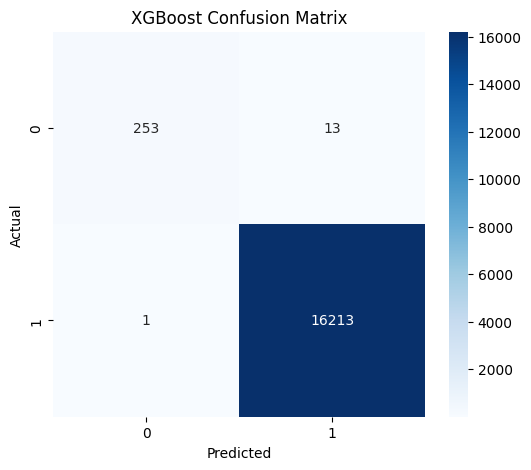

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


max_depth decide karta hai ke branches kitni levels tak neeche ja sakti hain. Depth bohat zyada ho to model training data ko yaad karke overfit kar sakta hai; bohat kam ho to important patterns miss kar sakta hai. RandomizedSearchCV in options ko try karke dekhega ke hamare data ke liye kaunsi depth best hai.

In [81]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = { #batata hai ke kin parameters ki kin values ko try karna hai.
    "n_estimators": [100, 200, 300], #Random Forest mein kitne decision trees banane hain.
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10], #node ko further split karne ke liye minimum kitne samples hone chahiye.
    "min_samples_leaf": [1, 2, 4], #har final leaf mein minimum kitne samples hone chahiye.
    "max_features": ["sqrt", "log2", None]
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42, #random selection ko fixed rakhta hai taake dobara run karne par same combinations/results milen.
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="f1", #combinations ko F1-score ke basis par compare karega.
    cv=3, #training data ko 3 parts mein divide karke 3-fold cross-validation karega: 2 parts par train, 1 par validation; phir rotate karke 3 baar test karega.
    random_state=42,
    n_jobs=-1,
    verbose=1 #screen par process ki progress/status show karega. verbose=0 hota to kuch progress nahi dikhata.
)

rf_random_search.fit(X_train_processed, y_train)

print("Best RF Parameters:")
print(rf_random_search.best_params_)

print("\nBest RF CV F1 Score:")
print(rf_random_search.best_score_) #cross-validation mein un best parameters ka average F1-score batata hai.

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}

Best RF CV F1 Score:
0.9993756567744162


In [82]:
best_rf_model = rf_random_search.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test_processed)

y_prob_rf_tuned = best_rf_model.predict_proba(
    X_test_processed
)[:, 1]

evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned
)


Tuned Random Forest
------------------------------
Accuracy : 0.9990
Precision: 0.9991
Recall   : 0.9999
F1 Score : 0.9995
ROC-AUC  : 0.9904


In [83]:
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search.fit(X_train_processed, y_train)

print("Best XGBoost Parameters:")
print(xgb_random_search.best_params_)

print("\nBest XGBoost CV F1 Score:")
print(xgb_random_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best XGBoost Parameters:
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Best XGBoost CV F1 Score:
0.9998920773782607


In [84]:
best_xgb_model = xgb_random_search.best_estimator_

y_pred_xgb_tuned = best_xgb_model.predict(X_test_processed)

y_prob_xgb_tuned = best_xgb_model.predict_proba(
    X_test_processed
)[:, 1]

evaluate_model(
    "Tuned XGBoost",
    y_test,
    y_pred_xgb_tuned,
    y_prob_xgb_tuned
)


Tuned XGBoost
------------------------------
Accuracy : 0.9998
Precision: 0.9998
Recall   : 1.0000
F1 Score : 0.9999
ROC-AUC  : 0.9996


In [85]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf_tuned),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_xgb_tuned)
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.983981,0.985747,0.998150,0.991910,0.964800
1,Random Forest,0.995874,0.996128,0.999692,0.997907,0.994712
2,Tuned Random Forest,0.999029,0.999076,0.999938,0.999507,0.990414
3,XGBoost,0.999150,0.999199,0.999938,0.999568,0.999773
4,Tuned XGBoost,0.999757,0.999753,1.000000,0.999877,0.999553


In [86]:
best_model = best_xgb_model

print("Final Model: Tuned XGBoost")
print(best_model)

Final Model: Tuned XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [87]:
import joblib

# Save final model
joblib.dump(best_model, "churn_xgboost_model.pkl")

# Save preprocessing pipeline
joblib.dump(preprocessor, "churn_preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [88]:

loaded_model = joblib.load("churn_xgboost_model.pkl")
loaded_preprocessor = joblib.load("churn_preprocessor.pkl")

# Test prediction using the loaded model
y_pred_loaded = loaded_model.predict(X_test_processed)

print("Loaded model accuracy:",
      accuracy_score(y_test, y_pred_loaded))

Loaded model accuracy: 0.999757281553398


In [89]:
# Take one customer from the test data
sample_customer = X_test.iloc[[0]]

# Preprocess the customer
sample_processed = loaded_preprocessor.transform(sample_customer)

# Predict churn
prediction = loaded_model.predict(sample_processed)[0]

# Churn probability
probability = loaded_model.predict_proba(sample_processed)[0][1]

print("Prediction:", prediction)
print("Churn Probability:", probability)

Prediction: 1
Churn Probability: 1.0


In [90]:
if probability < 0.3:
    segment = "Low"
elif probability <= 0.7:
    segment = "Medium"
else:
    segment = "High"

print("Churn Probability:", probability)
print("Churn Segment:", segment)

Churn Probability: 1.0
Churn Segment: High


In [91]:
def predict_churn(customer_data):

    # Preprocess input
    customer_processed = loaded_preprocessor.transform(customer_data)

    # Prediction
    prediction = loaded_model.predict(customer_processed)[0]

    # Probability
    probability = loaded_model.predict_proba(
        customer_processed
    )[0][1]

    # Segment
    if probability < 0.3:
        segment = "Low"
    elif probability <= 0.7:
        segment = "Medium"
    else:
        segment = "High"

    return prediction, probability, segment

**Streamlit App**

In [92]:
!pip install streamlit

In [93]:
!pip install -q streamlit pyngrok

In [94]:
!streamlit run app.py &>/content/streamlit.log &

**Gemini API KEY**

In [95]:
!pip install -q google-generativeai

In [97]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import os

from google import genai


# ==============================
# Load Model and Preprocessor
# ==============================

model = joblib.load("churn_xgboost_model.pkl")
preprocessor = joblib.load("churn_preprocessor.pkl")


# ==============================
# Gemini API
# ==============================

gemini_api_key = os.getenv("GEMINI_API_KEY")

if gemini_api_key:
    client = genai.Client(api_key=gemini_api_key)
else:
    client = None


# ==============================
# Page Configuration
# ==============================

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)


# ==============================
# App Title
# ==============================

st.title("📊 Customer Churn Prediction")

st.write(
    "Enter customer information to predict churn probability "
    "and understand the customer's risk."
)


# ==============================
# Customer Information
# ==============================

st.header("👤 Customer Information")

col1, col2 = st.columns(2)

with col1:

    age = st.number_input(
        "Age",
        min_value=18,
        max_value=100,
        value=30
    )

    gender = st.selectbox(
        "Gender",
        ["Male", "Female"]
    )

    tenure = st.number_input(
        "Tenure",
        min_value=1,
        value=12
    )


with col2:

    subscription_type = st.selectbox(
        "Subscription Type",
        ["Basic", "Standard", "Premium"]
    )

    contract_length = st.selectbox(
        "Contract Length",
        ["Monthly", "Quarterly", "Annual"]
    )


# ==============================
# Usage Information
# ==============================

st.header("📈 Usage Information")

col1, col2 = st.columns(2)

with col1:

    usage_frequency = st.number_input(
        "Usage Frequency",
        min_value=0,
        value=10
    )

    support_calls = st.number_input(
        "Support Calls",
        min_value=0,
        value=2
    )


with col2:

    last_interaction = st.number_input(
        "Last Interaction",
        min_value=1,
        value=10
    )


# ==============================
# Payment Information
# ==============================

st.header("💳 Payment Information")

col1, col2 = st.columns(2)

with col1:

    payment_delay = st.number_input(
        "Payment Delay",
        min_value=0,
        value=5
    )

with col2:

    total_spend = st.number_input(
        "Total Spend",
        min_value=0.0,
        value=500.0
    )


# ==============================
# Prediction
# ==============================

if st.button(
    " Predict Churn",
    use_container_width=True
):

    total_activity = (
        usage_frequency + support_calls
    )

    support_calls_per_tenure = (
        support_calls / (tenure + 1)
    )

    payment_delay_per_tenure = (
        payment_delay / (tenure + 1)
    )


    customer_data = pd.DataFrame({

        "Age": [age],

        "Gender": [gender],

        "Tenure": [tenure],

        "Usage Frequency": [
            usage_frequency
        ],

        "Support Calls": [
            support_calls
        ],

        "Payment Delay": [
            payment_delay
        ],

        "Subscription Type": [
            subscription_type
        ],

        "Contract Length": [
            contract_length
        ],

        "Total Spend": [
            total_spend
        ],

        "Last Interaction": [
            last_interaction
        ],

        "Total_Activity": [
            total_activity
        ],

        "Support_Calls_per_Tenure": [
            support_calls_per_tenure
        ],

        "Payment_Delay_per_Tenure": [
            payment_delay_per_tenure
        ]
    })


    customer_processed = preprocessor.transform(
        customer_data
    )


    prediction = model.predict(
        customer_processed
    )[0]

    probability = model.predict_proba(
        customer_processed
    )[0][1]


    # ==============================
    # Risk Segment
    # ==============================

    if probability < 0.3:

        segment = "Low"

    elif probability <= 0.7:

        segment = "Medium"

    else:

        segment = "High"


    # ==============================
    # Prediction Result
    # ==============================

    st.divider()

    st.header("📊 Prediction Result")

    col1, col2, col3 = st.columns(3)


    with col1:

        st.metric(
            "Churn Probability",
            f"{probability:.2%}"
        )


    with col2:

        st.metric(
            "Risk Segment",
            segment
        )


    with col3:

        if prediction == 1:

            st.metric(
                "Prediction",
                "Likely to Churn"
            )

        else:

            st.metric(
                "Prediction",
                "Unlikely to Churn"
            )


    if segment == "High":

        st.error(
            "⚠️ High churn risk. "
            "Immediate retention attention may be required."
        )

    elif segment == "Medium":

        st.warning(
            "⚠️ Medium churn risk. "
            "The customer should be monitored."
        )

    else:

        st.success(
            "✅ Low churn risk. "
            "The customer currently appears stable."
        )


    # ==============================
    # Customer Summary
    # ==============================

    st.subheader("🔎 Customer Summary")

    st.write(f"**Age:** {age}")
    st.write(f"**Tenure:** {tenure}")
    st.write(f"**Usage Frequency:** {usage_frequency}")
    st.write(f"**Support Calls:** {support_calls}")
    st.write(f"**Payment Delay:** {payment_delay}")
    st.write(f"**Contract:** {contract_length}")
    st.write(f"**Total Spend:** {total_spend}")


    # ==============================
    # Gemini AI Explanation
    # ==============================

    st.divider()

    st.header("🤖 AI-Powered Explanation")


    if client is None:

        st.warning(
            "Gemini API key is not configured."
        )

    else:

        safe_summary = f"""
        Churn probability: {probability:.2%}
        Risk segment: {segment}
        Prediction: {
            "Likely to churn"
            if prediction == 1
            else "Unlikely to churn"
        }

        Customer features:

        Age: {age}
        Tenure: {tenure}
        Usage Frequency: {usage_frequency}
        Support Calls: {support_calls}
        Payment Delay: {payment_delay}
        Subscription Type: {subscription_type}
        Contract Length: {contract_length}
        Total Spend: {total_spend}
        Last Interaction: {last_interaction}
        """


        prompt = f"""
You are a customer retention analyst.

Analyze the following customer churn prediction.

Use ONLY the information provided below.
Do not invent information.

Explain the result in simple, professional language.

Include:

1. Why the customer has this risk level.
2. The 2 or 3 most important factors visible in the provided data.
3. Two practical customer-retention suggestions.

Keep the explanation concise.

Customer Summary:

{safe_summary}
"""


        try:

            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt
            )

            st.write(response.text)

        except Exception as e:

            st.warning(
                "Gemini explanation could not be generated."
            )

            st.caption(
                f"Error: {e}"
            )

Overwriting app.py


deletd my gemini api code

In [99]:
!pip install -q pyngrok

deleted my api code for ngrok

In [102]:
!ps aux | grep streamlit

root        8971  2.1  1.8 1044836 247348 ?      Sl   13:13   0:10 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       11222 13.8  0.5 451828 71636 ?        Sl   13:20   0:03 /usr/bin/python3 /usr/local/bin/streamlit run app.py
root       11441  0.0  0.0   7340  3568 ?        S    13:21   0:00 /bin/bash -c ps aux | grep streamlit
root       11443  0.0  0.0   6544  2336 ?        S    13:21   0:00 grep streamlit


In [103]:
!pip install -q streamlit

In [104]:
!streamlit --version

Streamlit, version 1.63.0


In [137]:
from pathlib import Path

path = Path("app.py")
text = path.read_text()

old = '''            st.info("Sending request to Gemini...")

            response = gemini_client.models.generate_content(
                model="gemini-2.5-flash",
                contents="Give one short sentence explaining customer churn."
            )

            st.success("Gemini response received!")
            st.write(response.text)
'''

new = '''            st.info("Sending request to Gemini...")

            response = gemini_client.models.generate_content(
                model="gemini-2.5-flash",
                contents=f"""
You are a customer retention analyst.

Analyze this customer churn prediction.

Churn probability: {probability:.2%}
Risk segment: {segment}
Prediction: {"Likely to churn" if prediction == 1 else "Unlikely to churn"}

Customer information:
Age: {age}
Tenure: {tenure}
Usage Frequency: {usage_frequency}
Support Calls: {support_calls}
Payment Delay: {payment_delay}
Subscription Type: {subscription_type}
Contract Length: {contract_length}
Total Spend: {total_spend}
Last Interaction: {last_interaction}

Explain in simple professional language:
1. Why the customer has this risk level.
2. The 2 most important factors visible in the data.
3. Two practical retention suggestions.

Use ONLY the information provided.
Keep the answer concise.
"""
            )

            if response.text:
                st.success("AI explanation generated!")
                st.markdown(response.text)
            else:
                st.warning("Gemini returned an empty response.")
'''

if old in text:
    text = text.replace(old, new)
    path.write_text(text)
    print("Customer-specific Gemini explanation restored.")
else:
    print("Target Gemini test code not found.")

Customer-specific Gemini explanation restored.


In [138]:
!pkill -f streamlit

In [140]:
!streamlit run app.py &>/content/streamlit.log &

In [141]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("Public URL:")
print(public_url)

Public URL:
NgrokTunnel: "https://juicy-silenced-datebook.ngrok-free.dev" -> "http://localhost:8501"


In [118]:
!tail -80 /content/streamlit.log



2026-09-15 13:30:13.703 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.21.222.59:8501



In [142]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
xgboost
joblib
google-genai

Writing requirements.txt
